In [1]:
import numpy as np, awkward as ak, uproot, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [2]:
FILE = "/ceph/omunkombwe/fit__idea_o1_v03_60.root"
TREE = "events"

In [3]:
pt_bins = np.linspace(0.65, 5, 25)

In [4]:
# collectionIDs for fitted-track hit refs 
CID = {
    'DCH_DigiCollection': np.uint32(3486206992), 
}
COUNTABLE_CIDS = {CID['DCH_DigiCollection']}  

In [5]:
with uproot.open(FILE) as f:
    t = f[TREE]
    arr = t.arrays([
        # ---- Truth (kinematics + vertex) ----
        "MCParticles.momentum.x","MCParticles.momentum.y","MCParticles.momentum.z",
        "MCParticles.PDG","MCParticles.generatorStatus",
    
        # ---- Fitted tracks → flattened hit refs ----
        "CDCHTracks.trackerHits_begin", "Fitted_tracks_muon.trackerHits_begin", "Fitted_tracks_muon.trackerHits_end",
        "CDCHTracks.trackerHits_end",
        "_CDCHTracks_trackerHits.index", "_Fitted_tracks_muon_trackerHits.index", "_Fitted_tracks_muon_trackerHits.collectionID",
        "_CDCHTracks_trackerHits.collectionID",

        # ---- Sim links (digi ↔ sim ↔ MC) for ALL subdetectors ----
        "_DCH_DigiSimAssociationCollection_from.index",
        "_DCH_DigiSimAssociationCollection_to.index",
        "_DCHCollection_particle.index",
    ], how=dict)

In [6]:
mc_px, mc_py, mc_pz = arr["MCParticles.momentum.x"], arr["MCParticles.momentum.y"], arr["MCParticles.momentum.z"]
mc_pdg, mc_gen = arr["MCParticles.PDG"], arr["MCParticles.generatorStatus"]

In [7]:
T_hit_beg  = arr["Fitted_tracks_muon.trackerHits_begin"]
T_hit_end  = arr["Fitted_tracks_muon.trackerHits_end"]
T_hit_idx  = arr["_Fitted_tracks_muon_trackerHits.index"]
T_hit_cid  = arr["_Fitted_tracks_muon_trackerHits.collectionID"]

In [8]:
# ---- Links (digis ↔ simhits ↔ MC)
DCH_from = arr["_DCH_DigiSimAssociationCollection_from.index"]
DCH_to   = arr["_DCH_DigiSimAssociationCollection_to.index"]
DCH_sim2mc = arr["_DCHCollection_particle.index"]


In [9]:
# ---- Truth kinematics ----
mc_pt = np.sqrt(mc_px**2 + mc_py**2)
is_mu = (abs(mc_pdg) == 13)
is_final = (mc_gen == 1)

In [10]:
# ==========================================================
def make_digi_to_mc_map(digi_from, digi_to_sim, sim_to_mc):
    
    out = []
    
    for evt, (frm, to, sim2mc_evt) in enumerate(zip(digi_from, digi_to_sim, sim_to_mc)):
        frm_evt = ak.to_numpy(frm)
        to_evt = ak.to_numpy(to)
        sim2mc_arr = ak.to_numpy(sim2mc_evt)

        acc = defaultdict(lambda: defaultdict(int))  # acc[d][mc] -> count
        for d, s in zip(frm_evt, to_evt):
            if d is None or s is None:
                continue
            if s < 0 or s >= len(sim2mc_arr):
                continue
            d_int = int(d)
        
            mcid = sim2mc_arr[s]
            if mcid is None or mcid < 0:
                continue
            acc[d_int][int(mcid)] += 1
        # choose max-count MC per digi
        mapping = {}
        for d, bucket in acc.items():
            # deterministic tie-break: highest count, then largest mcid
            best_mcid, best_cnt = None, -1
            for mcid, cnt in bucket.items():
                if (cnt > best_cnt) or (cnt == best_cnt and (best_mcid is None or mcid > best_mcid)):
                    best_mcid, best_cnt = mcid, cnt
            mapping[int(d)] = best_mcid
        out.append(mapping)
    return out


In [11]:
# Build majority maps for drift chamber only
dch_map = make_digi_to_mc_map(DCH_from, DCH_to, DCH_sim2mc) #valid_mask=DCH_residual_ok


In [12]:
# hit→MC for fitted-track hits -- maps to label each fitted-track hit by its MC id --
def hit_to_mc_for_event(evt, col_id, idx):
    if col_id == CID['DCH_DigiCollection']:
        return dch_map[evt].get(int(idx), None)
    return None


In [13]:
# SIM-HIT totals per MC for drift chamber only (denominator uses all DCH sim-hits)
# ==========================================================
def truth_simhits_all(evt):
    counts = Counter()
    for mcid in ak.to_numpy(DCH_sim2mc[evt]):
        if mcid is None or mcid < 0:
            continue
        counts[int(mcid)] += 1
    return counts


In [14]:
# ---Binning tallies--
den = np.zeros(len(pt_bins)-1)
num = np.zeros(len(pt_bins)-1)

# Diagnostics for truth↔reco matching
purity_vals = []
hit_eff_vals = []
shared_vals = []
debug_samples = []
DEBUG_SAMPLE_LIMIT = 8


In [15]:
# ---------------- Main events loop -----------------
n_events = len(mc_pt)
for evt in range(n_events):
    # truth preselection
    mask_truth = (is_mu[evt]) & (is_final[evt])
    if not ak.any(mask_truth):
        continue

    mask_truth_np = ak.to_numpy(mask_truth)
    mc_pt_evt = ak.to_numpy(mc_pt[evt])

    # SIM-HIT totals per MC (hit-eff denominator) and reconstructable set
    truth_hits_by_mc = truth_simhits_all(evt)

    truth_ids_evt = np.flatnonzero(mask_truth_np)
    pts_evt = mc_pt_evt[mask_truth_np]

    recon_ids, recon_pts = [], []  # used to fill den via binning
    for tid, pt in zip(truth_ids_evt, pts_evt):
        if truth_hits_by_mc.get(int(tid), 0):
            recon_ids.append(int(tid))
            recon_pts.append(float(pt))
    if not recon_ids:
        continue

    pt_lookup = {tid: pt for tid, pt in zip(recon_ids, recon_pts)}

    # For each track, build contribution counts via majority digi→MC mapping
    beg_evt, end_evt = T_hit_beg[evt], T_hit_end[evt]
    idx_flat, col_flat = T_hit_idx[evt], T_hit_cid[evt]

    candidates = []  # (truth_id, shared, purity, hit_eff, total_track_hits)
    for b, e in zip(beg_evt, end_evt):
        if b is None or e is None or e <= b:
            continue
        ids = idx_flat[b:e]
        cols = col_flat[b:e]

        total_track_hits = 0
        contrib = Counter()  # hits on this track coming from each MC

        for idx_val, col_val in zip(ids, cols):
            if idx_val is None or col_val is None:
                continue
            col_val = np.uint32(col_val)
            if col_val not in COUNTABLE_CIDS:
                continue
            total_track_hits += 1
            mcid = hit_to_mc_for_event(evt, col_val, int(idx_val))
            if mcid is None:
                continue
            contrib[mcid] += 1

        if total_track_hits == 0 or not contrib:
            continue

        best_mcid, shared = contrib.most_common(1)[0]
        purity = shared / float(total_track_hits)
        
        print( f"Event {evt} Track hits: {total_track_hits}, Best MCID: {best_mcid}, Shared: {shared}, Purity: {purity:.3f}" )

        truth_total = float(truth_hits_by_mc.get(best_mcid, 0))  # SIM-HITS denominator
        hit_eff = (shared / truth_total) if truth_total > 0 else 0.0

        # ===== thresholds =====
        if (purity >= 0.75) and (hit_eff >= 0.75) and (shared):  # V>= nhit_min
            candidates.append((best_mcid, shared, purity, hit_eff, total_track_hits))

    # ====================================
    # one-to-one truth↔track: keep the candidate with largest 'shared'
    best_by_truth = {}
    for mcid, shared, pur, hef, tot_hits in candidates:
        prev = best_by_truth.get(mcid)
        if (prev is None) or (shared > prev['shared']):
            best_by_truth[mcid] = {
                'shared': shared,
                'purity': pur,
                'hit_eff': hef,
                'track_hits': tot_hits,
            }

    for mcid, stats in best_by_truth.items():
        purity_vals.append(stats['purity'])
        hit_eff_vals.append(stats['hit_eff'])
        shared_vals.append(stats['shared'])
        if len(debug_samples) < DEBUG_SAMPLE_LIMIT:
            pt_val = pt_lookup.get(mcid)
            if pt_val is None and 0 <= mcid < len(mc_pt_evt):
                pt_val = float(mc_pt_evt[mcid])
            debug_samples.append({
                'event': evt,
                'truth_id': mcid,
                'pt_GeV': float(pt_val) if pt_val is not None else float('nan'),
                'shared_hits': stats['shared'],
                'track_hits': stats['track_hits'],
                'truth_hits': truth_hits_by_mc.get(mcid, 0),
                'purity': stats['purity'],
                'hit_eff': stats['hit_eff'],
            })

    matched_truth_ids = set(best_by_truth.keys())

    # fill num/den by pT bins for reconstructable truths
    bins_idx = np.digitize(recon_pts, pt_bins) - 1
    for tid, b in zip(recon_ids, bins_idx):
        if 0 <= b < len(den):
            den[b] += 1
            if tid in matched_truth_ids:
                num[b] += 1
# ---------------- End of events loop -----------------


Event 0 Track hits: 54, Best MCID: 0, Shared: 54, Purity: 1.000
Event 1 Track hits: 48, Best MCID: 0, Shared: 48, Purity: 1.000
Event 2 Track hits: 45, Best MCID: 0, Shared: 45, Purity: 1.000
Event 3 Track hits: 44, Best MCID: 0, Shared: 44, Purity: 1.000
Event 4 Track hits: 40, Best MCID: 0, Shared: 40, Purity: 1.000
Event 5 Track hits: 40, Best MCID: 0, Shared: 40, Purity: 1.000
Event 6 Track hits: 47, Best MCID: 0, Shared: 47, Purity: 1.000
Event 7 Track hits: 52, Best MCID: 0, Shared: 52, Purity: 1.000
Event 8 Track hits: 56, Best MCID: 0, Shared: 56, Purity: 1.000
Event 9 Track hits: 37, Best MCID: 0, Shared: 37, Purity: 1.000
Event 10 Track hits: 48, Best MCID: 0, Shared: 48, Purity: 1.000
Event 11 Track hits: 47, Best MCID: 0, Shared: 47, Purity: 1.000
Event 12 Track hits: 57, Best MCID: 0, Shared: 57, Purity: 1.000
Event 13 Track hits: 55, Best MCID: 0, Shared: 55, Purity: 1.000
Event 14 Track hits: 43, Best MCID: 0, Shared: 43, Purity: 1.000
Event 15 Track hits: 51, Best MCID:

In [16]:
# Diagnostics printout to verify truth↔reco matching quality
print("=== Truth↔Reco matching diagnostics ===")
reconstructable_total = int(np.sum(den))
matched_total = len(purity_vals)
print(f"Matched truth tracks: {matched_total} / {reconstructable_total} reconstructable candidates")
if reconstructable_total:
    print(f"Global match efficiency (all bins combined): {matched_total / reconstructable_total:.3f}")

if purity_vals:
    def describe(name, values):
        arr = np.asarray(values, dtype=float)
        print(f"{name:<12} mean={arr.mean():.3f}  std={arr.std(ddof=0):.3f}  median={np.median(arr):.3f}  min={arr.min():.3f}  5%tile={np.percentile(arr, 5):.3f}")
    describe("Purity", purity_vals)
    describe("Hit eff.", hit_eff_vals)
    describe("Shared hits", shared_vals)
else:
    print("No tracks passed the purity/hit-eff cuts — check the event loop selections.")

if debug_samples:
    print(f"Sample matches (first {len(debug_samples)} entries):")
    header = "evt  truth  pt[GeV]  shared/track  truthHits  purity  hitEff"
    print(header)
    print("-" * len(header))
    for row in debug_samples:
        ratio = f"{row['shared_hits']}/{row['track_hits']}"
        print(f"{row['event']:4d}  {row['truth_id']:5d}  {row['pt_GeV']:7.3f}   {ratio:>9}    {int(row['truth_hits']):5d}   {row['purity']:.2f}   {row['hit_eff']:.2f}")
else:
    print("No debug samples captured (increase DEBUG_SAMPLE_LIMIT for more rows).")


=== Truth↔Reco matching diagnostics ===
Matched truth tracks: 4531 / 4722 reconstructable candidates
Global match efficiency (all bins combined): 0.960
Purity       mean=1.000  std=0.004  median=1.000  min=0.772  5%tile=1.000
Hit eff.     mean=0.968  std=0.057  median=1.000  min=0.750  5%tile=0.831
Shared hits  mean=49.028  std=7.751  median=49.000  min=7.000  5%tile=37.000
Sample matches (first 8 entries):
evt  truth  pt[GeV]  shared/track  truthHits  purity  hitEff
------------------------------------------------------------
   0      0    2.885       54/54       54   1.00   1.00
   1      0    3.417       48/48       52   1.00   0.92
   2      0    1.448       45/45       45   1.00   1.00
   3      0    1.802       44/44       44   1.00   1.00
   4      0    1.666       40/40       40   1.00   1.00
   5      0    1.611       40/40       47   1.00   0.85
   6      0    3.903       47/47       47   1.00   1.00
   7      0    3.939       52/52       52   1.00   1.00


In [17]:
# Wald interval (~68%)
eff, err_wald = [], []
Z = 1
for k, n in zip(num, den):
    if n == 0:
        eff.append(np.nan); err_wald.append(np.nan); continue
    p_hat = k / n
    sigma = math.sqrt(max(p_hat*(1.0 - p_hat)/n, 0.0))
    eff.append(p_hat)
    err_wald.append(Z * sigma)


In [18]:

centers = 0.5*(pt_bins[:-1] + pt_bins[1:])


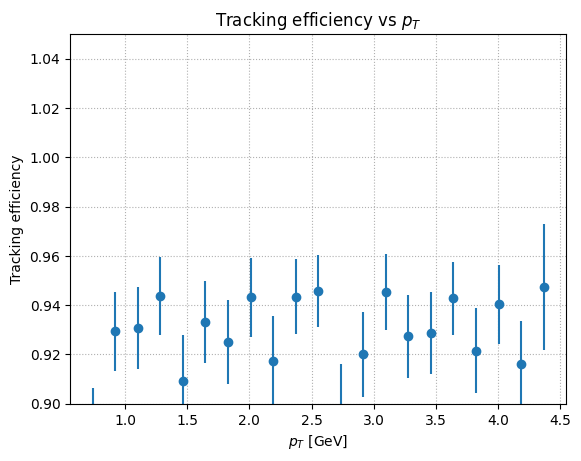

In [19]:
plt.figure()
plt.errorbar(centers, eff, yerr=err_wald, fmt='o', linestyle='None')
plt.ylim(0.9, 1.05)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracking efficiency")
plt.grid(True, ls=":")
plt.title(r"Tracking efficiency vs $p_T$")
plt.savefig("eff_vs_pt_wald.png", dpi=300)
plt.show()

